CDFS counts per bin: [0 0 0 1 0 3 1 1 2 1]
DECAM counts per bin: [ 3  5  8  8 12 16 16 16 14 10]
DECAM surface density: 4.26 ± 1.42 deg^-2
Global CDFS density: 4.26 ± 1.42 deg^-2
CDFS band (low, high): (np.float64(2.8431762731199406), np.float64(5.686352546239881))
Overdensity values: [20.3941845   7.17356004  4.33650433  1.61357192  2.42959608  3.11501717
  0.87599923  0.88223567  1.73955392  2.1299744 ]


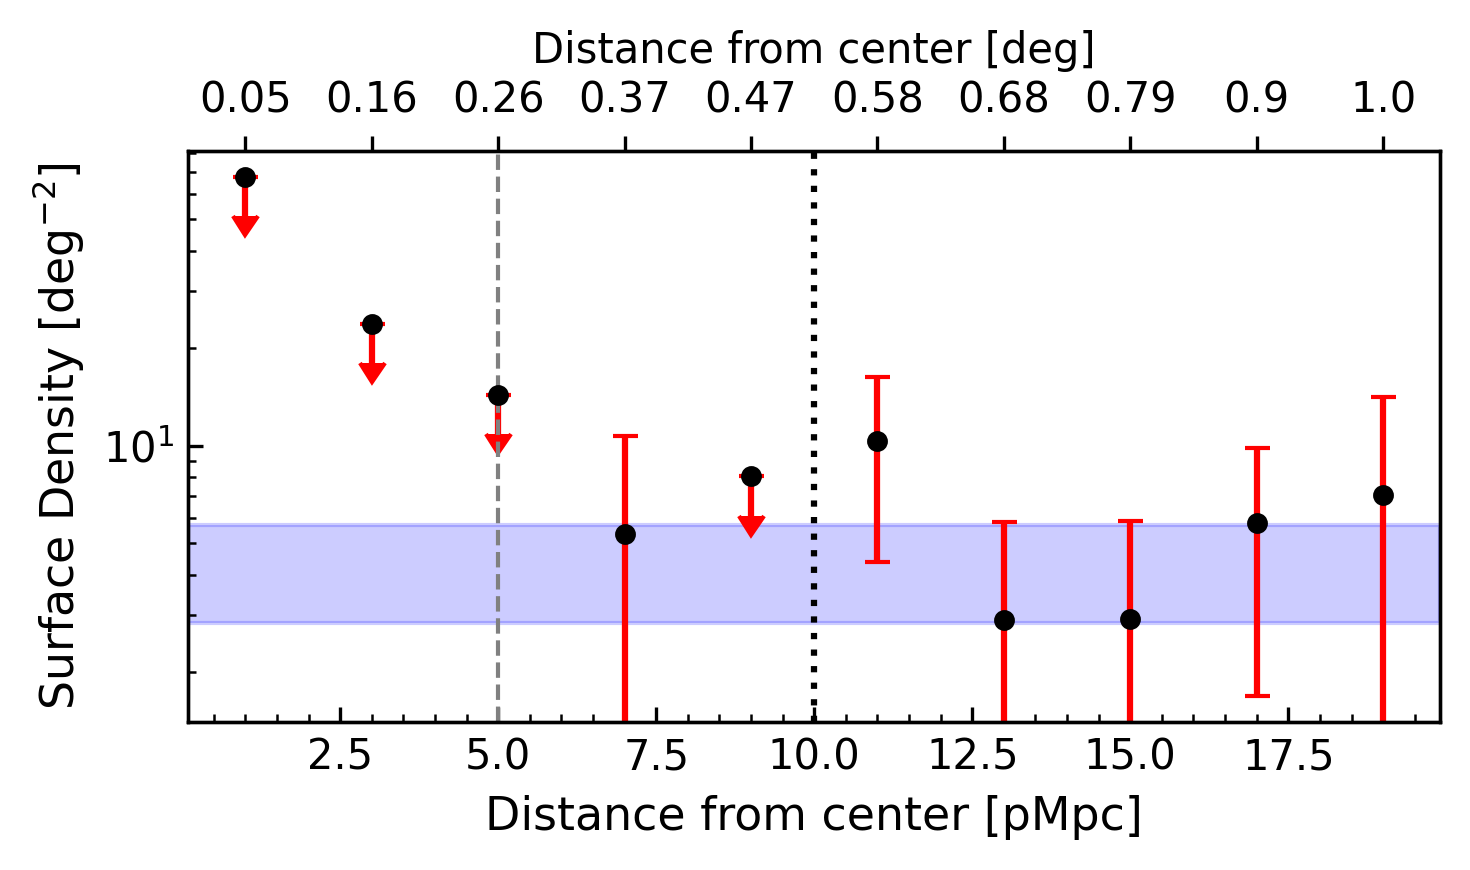

Saved: plots/cdfs_profile.png
Overdensity values: [25.93042227 14.41367814 13.84106994  9.89513278 11.5419545  12.61130919
 10.6498154   9.66296412  7.93145451  8.59144384]


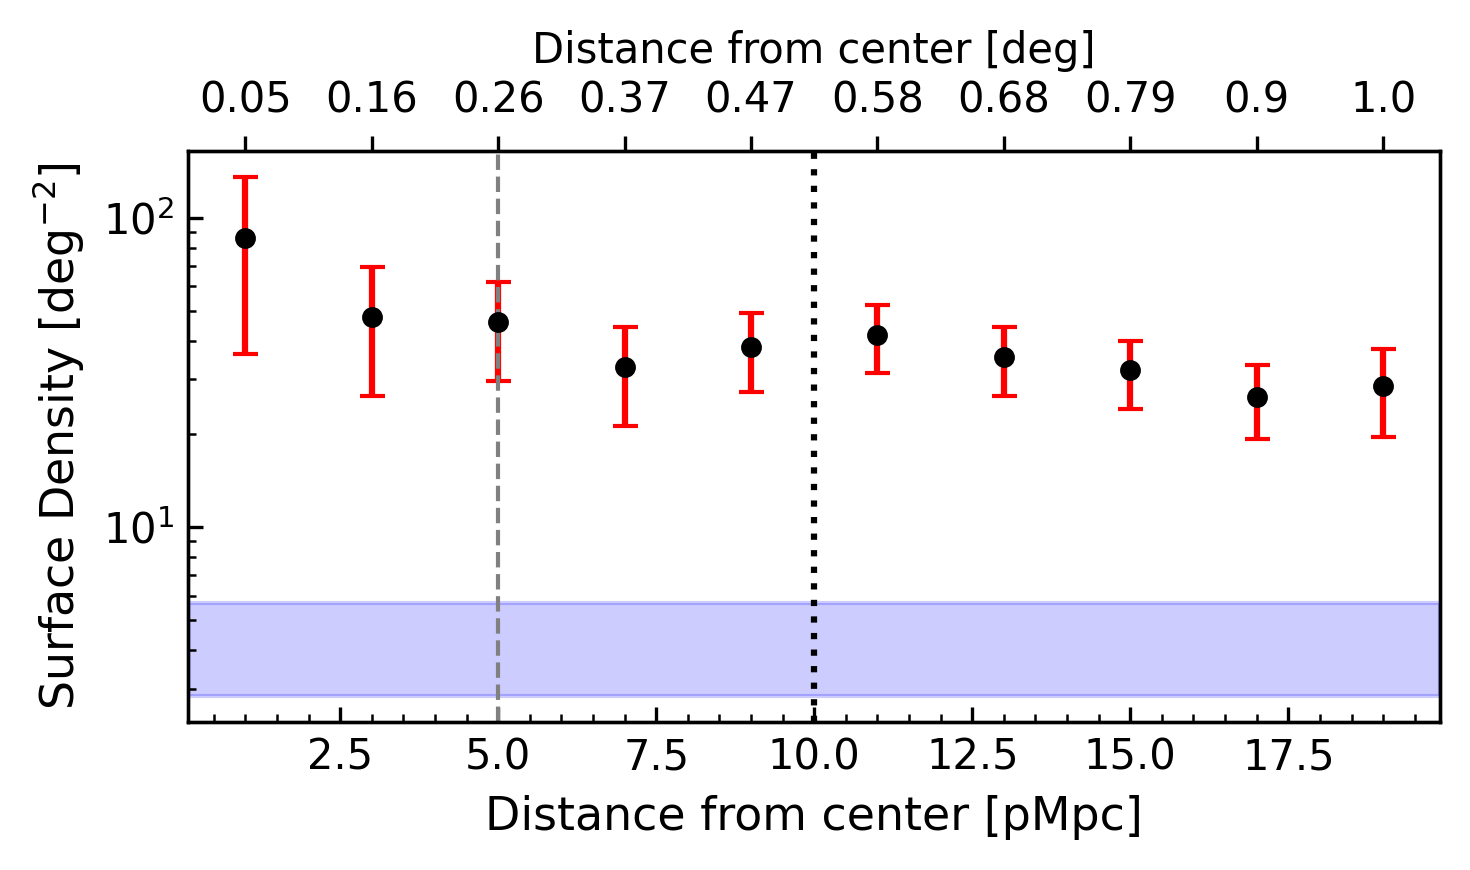

Saved: plots/decam_profile.png


In [ ]:
"""
Radial surface density (final corrected + publication-quality)
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os


# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
ARCSEC_PER_KPC_CO = COSMO.arcsec_per_kpc_comoving(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)


# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)

        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)

        good_pixels = (self.data > 0.5) & annulus # Assuming mask is binary (1 for good, 0 for bad)

        number_pixels = np.sum(good_pixels)
        return number_pixels * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)



def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras*u.deg, decs*u.deg)

    return center_coord.separation(sources)



def linear_fit(x, y):  # Simple linear regression ( Not used in final plots, but can be added if needed)
    slope, intercept, _, _, _ = linregress(x, y)
    return slope, intercept



#def compute_cdfs_band(counts, areas):
    """
    Compute global surface density band using Poisson statistics
    """

    #areas = np.array([a.value for a in areas])
    #total_area = np.sum(areas)
    #otal_counts = np.sum(counts)

    #print(f"Total CDFS counts: {total_counts}")
    #print(f"Total CDFS area: {total_area:.4f} deg^2")

    # Global surface density
    #rho = total_counts / total_area

    # Poisson errors (Gehrels 1986 approximation)
    #err_low = rho - (total_counts - np.sqrt(total_counts)) / total_area
    #err_high = ((total_counts + np.sqrt(total_counts)) / total_area) - rho

    #low = rho - err_low
    #high = rho + err_high

    #print(f"Global density: {rho:.2f} deg^-2")

    #return low, high


def compute_cdfs_band(counts, areas):
    areas = np.array([a.value for a in areas])
    total_area = np.sum(areas)
    total_counts = np.sum(counts)

    # mean surface density
    rho = total_counts / total_area

    rho_err = np.sqrt(total_counts) / total_area

    

    low = rho - rho_err
    high = rho + rho_err

    print(f"Global CDFS density: {rho:.2f} ± {rho_err:.2f} deg^-2")
    return low, high


def plot_profile(counts, areas, radii_mpc, radii_deg, outfile, band=None):

    areas = np.array([a.value for a in areas])

    valid = areas > 0
    counts = counts[valid]
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]
    radii_deg = radii_deg[valid]

    counts = counts.astype(float)

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841

    y = counts / areas
    yerr = np.sqrt(counts) / areas

    overdensity= y / 3.32
    
    print("Overdensity values:", overdensity)

    fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        y[nonzero_idx],
        yerr=yerr[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        y[zero_idx],
        yerr=yerr[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # optional fit
    #if len(nonzero_idx) > 2:
       # slope, intercept = linear_fit(radii_mpc[nonzero_idx], y[nonzero_idx])
        #fit_x = np.linspace(min(radii_mpc), max(radii_mpc), 200)
        #ax.plot(fit_x, slope*fit_x + intercept, 'r--', lw=1)

   
    if band is not None:
        ax.axhspan(band[0], band[1], color='blue', alpha=0.2)

    # physical scales
    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_yscale('log')
    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Surface Density [deg$^{-2}$]", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from center [deg]", fontsize=10)

    #max_radius = ARCSEC_PER_KPC_CO * 75 * u.Mpc
    #ax.axvline(max_radius.to(u.deg).value, ls=':', lw=1.2)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")


# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":

    CDFS_MASK_FILE = "/Users/aishwarya/Desktop/Mask/cdfs_mask.fits"
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"

    CDFS_CATALOG = "/Users/aishwarya/Desktop/source_cdfs_true.txt"
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

    cdfs = Mask(CDFS_MASK_FILE)
    decam = Mask(DECAM_MASK_FILE)

    cdfs_center_pix = (cdfs.data.shape[1]/2, cdfs.data.shape[0]/2)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC

    radii_pix_cdfs = radii_deg / cdfs.deg_per_pix
    radii_pix_decam = radii_deg / decam.deg_per_pix

    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    areas_cdfs = [
        cdfs.calculate_area(cdfs_center_pix, radii_pix_cdfs[i], radii_pix_cdfs[i+1])
        for i in range(len(radii_pix_cdfs)-1)
    ]

    areas_decam = [
        decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
        for i in range(len(radii_pix_decam)-1)
    ]

    dist_cdfs = calculate_distances(cdfs.center, CDFS_CATALOG)
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)

    dist_decam = dist_decam[dist_decam > 0*u.deg]

    counts_cdfs = np.array([
        np.sum((dist_cdfs >= radii_deg[i]) & (dist_cdfs < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])

    counts_decam = np.array([
        np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
        for i in range(len(radii_deg)-1)
    ])
    print("CDFS counts per bin:", counts_cdfs)
    print("DECAM counts per bin:", counts_decam)

    
    cdfs_band = compute_cdfs_band(counts_cdfs, areas_cdfs)
    print("CDFS band (low, high):", cdfs_band)

    os.makedirs("plots", exist_ok=True)

    plot_profile(
        counts_cdfs,
        areas_cdfs,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/cdfs_profile.png",
        band=cdfs_band
    )

    plot_profile(
        counts_decam,
        areas_decam,
        radii_mid_mpc.value,
        radii_mid_deg,
        "plots/decam_profile.png",
        band=cdfs_band
    )

In [ ]:

print("CDFS areas per bin [deg^2]:", [a.value for a in areas_cdfs])
print("DECAM areas per bin [deg^2]:", [a.value for a in areas_decam])


print("CDFS counts per bin:", counts_cdfs)
print("DECAM counts per bin:", counts_decam)

cdfs_band = compute_cdfs_band(counts_cdfs, areas_cdfs)
print("CDFS band (low, high):", cdfs_band)

y_cdfs = counts_cdfs / np.array([a.value for a in areas_cdfs])
y_decam = counts_decam / np.array([a.value for a in areas_decam])

print("CDFS surface densities [deg^-2]:", y_cdfs)
print("DECAM surface densities [deg^-2]:", y_decam)

CDFS areas per bin [deg^2]: [np.float64(0.02719000959984359), np.float64(0.07730026218919547), np.float64(0.12787213609582257), np.float64(0.18666959641208655), np.float64(0.22823467514213883), np.float64(0.29008329917417), np.float64(0.34384141968776044), np.float64(0.34141083869653543), np.float64(0.34630121615024956), np.float64(0.141412413204001)]
DECAM areas per bin [deg^2]: [np.float64(0.034847656874999994), np.float64(0.10448575874999998), np.float64(0.17409337312499998), np.float64(0.24351755624999996), np.float64(0.3131582118749999), np.float64(0.38213931937499995), np.float64(0.45252212624999993), np.float64(0.49873693499999994), np.float64(0.53166382875), np.float64(0.35058696187499994)]
CDFS counts per bin: [0 0 0 0 0 3 1 1 2 0]
DECAM counts per bin: [ 3  5  8  8 12 16 16 16 14 10]
Global CDFS density: 3.32 ± 1.25 deg^-2
CDFS band (low, high): (np.float64(2.0633160932741275), np.float64(4.570761877339068))
CDFS surface densities [deg^-2]: [ 0.          0.          0.       

In [20]:
from astropy.stats import poisson_conf_interval
print(poisson_conf_interval(10, interval='frequentist-confidence'))
print(10-10**0.5, 10+10**0.5)

[ 6.89130556 14.26694976]
6.83772233983162 13.16227766016838


# Overdensity

In [22]:
def plot_overdensity(counts, areas, radii_mpc, outfile, cdfs_band):

    areas = np.array([a.value for a in areas])
    valid = areas > 0

    counts = counts[valid].astype(float)
    areas = areas[valid]
    radii_mpc = radii_mpc[valid]

    zero_idx = np.where(counts == 0)[0]
    nonzero_idx = np.where(counts != 0)[0]

    counts[zero_idx] = 1.841

    sigma = counts / areas
    sigma_err = np.sqrt(counts) / areas

    # CDFS global density
    rho_cdfs = np.mean(cdfs_band)

    delta = (sigma - rho_cdfs) / rho_cdfs
    delta_err = sigma_err / rho_cdfs

    fig, ax = plt.subplots(figsize=(5,3), dpi=300)

    # detections
    ax.errorbar(
        radii_mpc[nonzero_idx],
        delta[nonzero_idx],
        yerr=delta_err[nonzero_idx],
        fmt='o',
        color='black',
        ecolor='red',
        capsize=3,
        ms=4
    )

    # upper limits
    ax.errorbar(
        radii_mpc[zero_idx],
        delta[zero_idx],
        yerr=delta_err[zero_idx]/3,
        fmt='o',
        color='black',
        ecolor='red',
        uplims=True,
        capsize=3,
        ms=4
    )

    # field level
    ax.axhline(0, color='blue', ls='--', lw=1)

    ax.axvline(5, ls='--', color='gray', lw=1)
    ax.axvline(10, ls=':', color='black', lw=1.5)

    ax.set_xlabel("Distance from center [pMpc]", fontsize=11)
    ax.set_ylabel("Overdensity δ", fontsize=11)

    ax.tick_params(direction='in', which='both')
    ax.minorticks_on()

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    print(f"Saved: {outfile}")

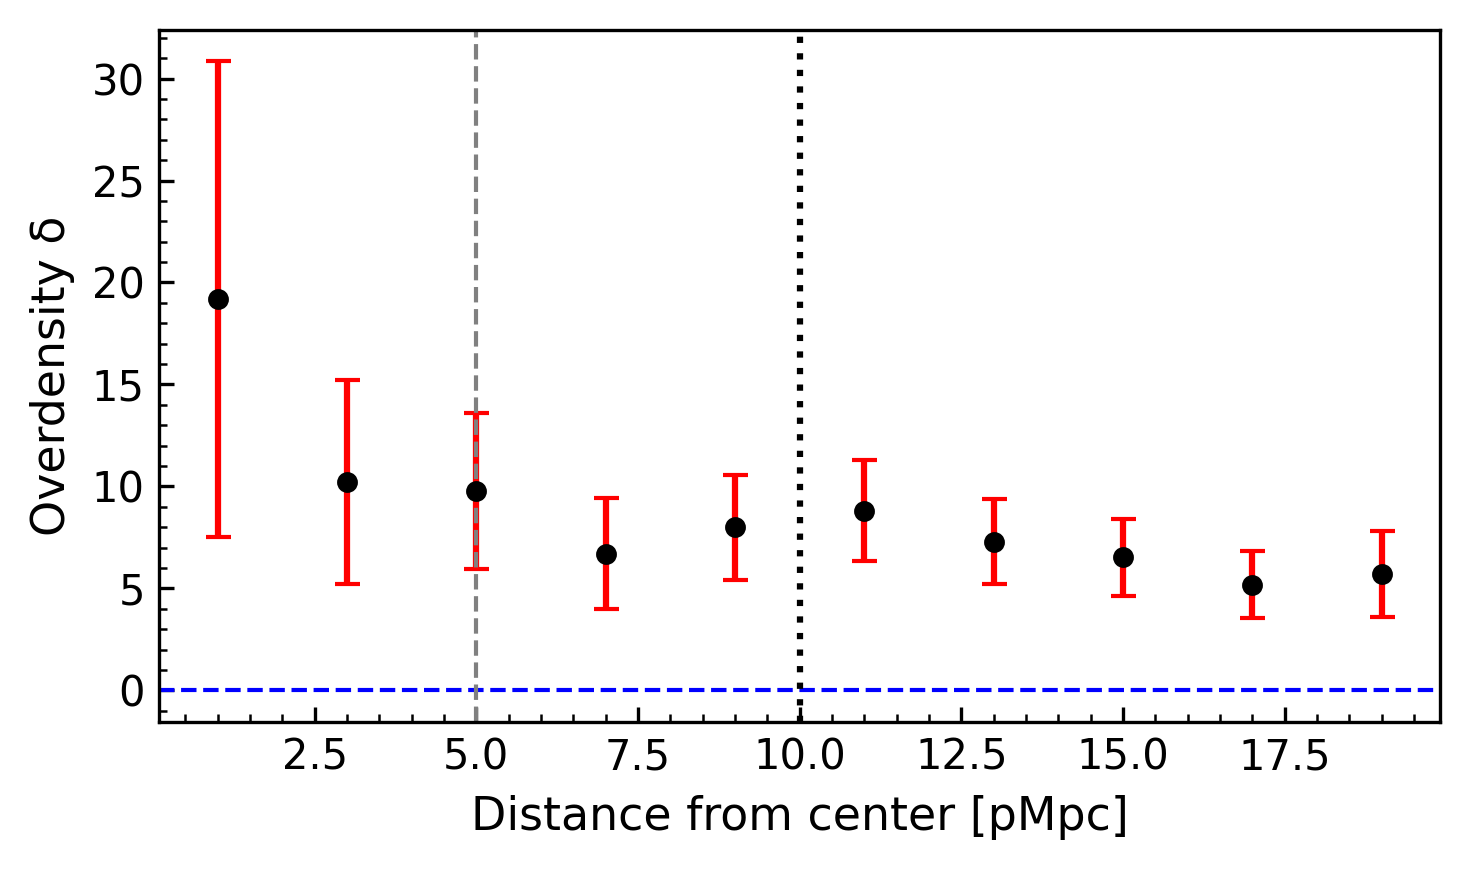

Saved: plots/decam_overdensity.png


In [23]:
plot_overdensity(
    counts_decam,
    areas_decam,
    radii_mid_mpc.value,
    "plots/decam_overdensity.png",
    cdfs_band
)

# Checking with LAEs

In [25]:
input_file = "/Users/aishwarya/Desktop/lae_ra_dec.txt"
output_file = "/Users/aishwarya/Desktop/lae_ra_dec_deg.txt"  # safer to create new file

# Load RA/Dec as strings
ras, decs = np.loadtxt(input_file, dtype=str, unpack=True)

# Convert to SkyCoord
coords = SkyCoord(ras, decs, unit=(u.hourangle, u.deg))

# Extract decimal degrees
ra_deg = coords.ra.deg
dec_deg = coords.dec.deg

# Save to new file
np.savetxt(output_file, np.column_stack([ra_deg, dec_deg]), fmt='%.8f', header="RA_deg Dec_deg")

print(f"Converted file saved as: {output_file}")

Converted file saved as: /Users/aishwarya/Desktop/lae_ra_dec_deg.txt


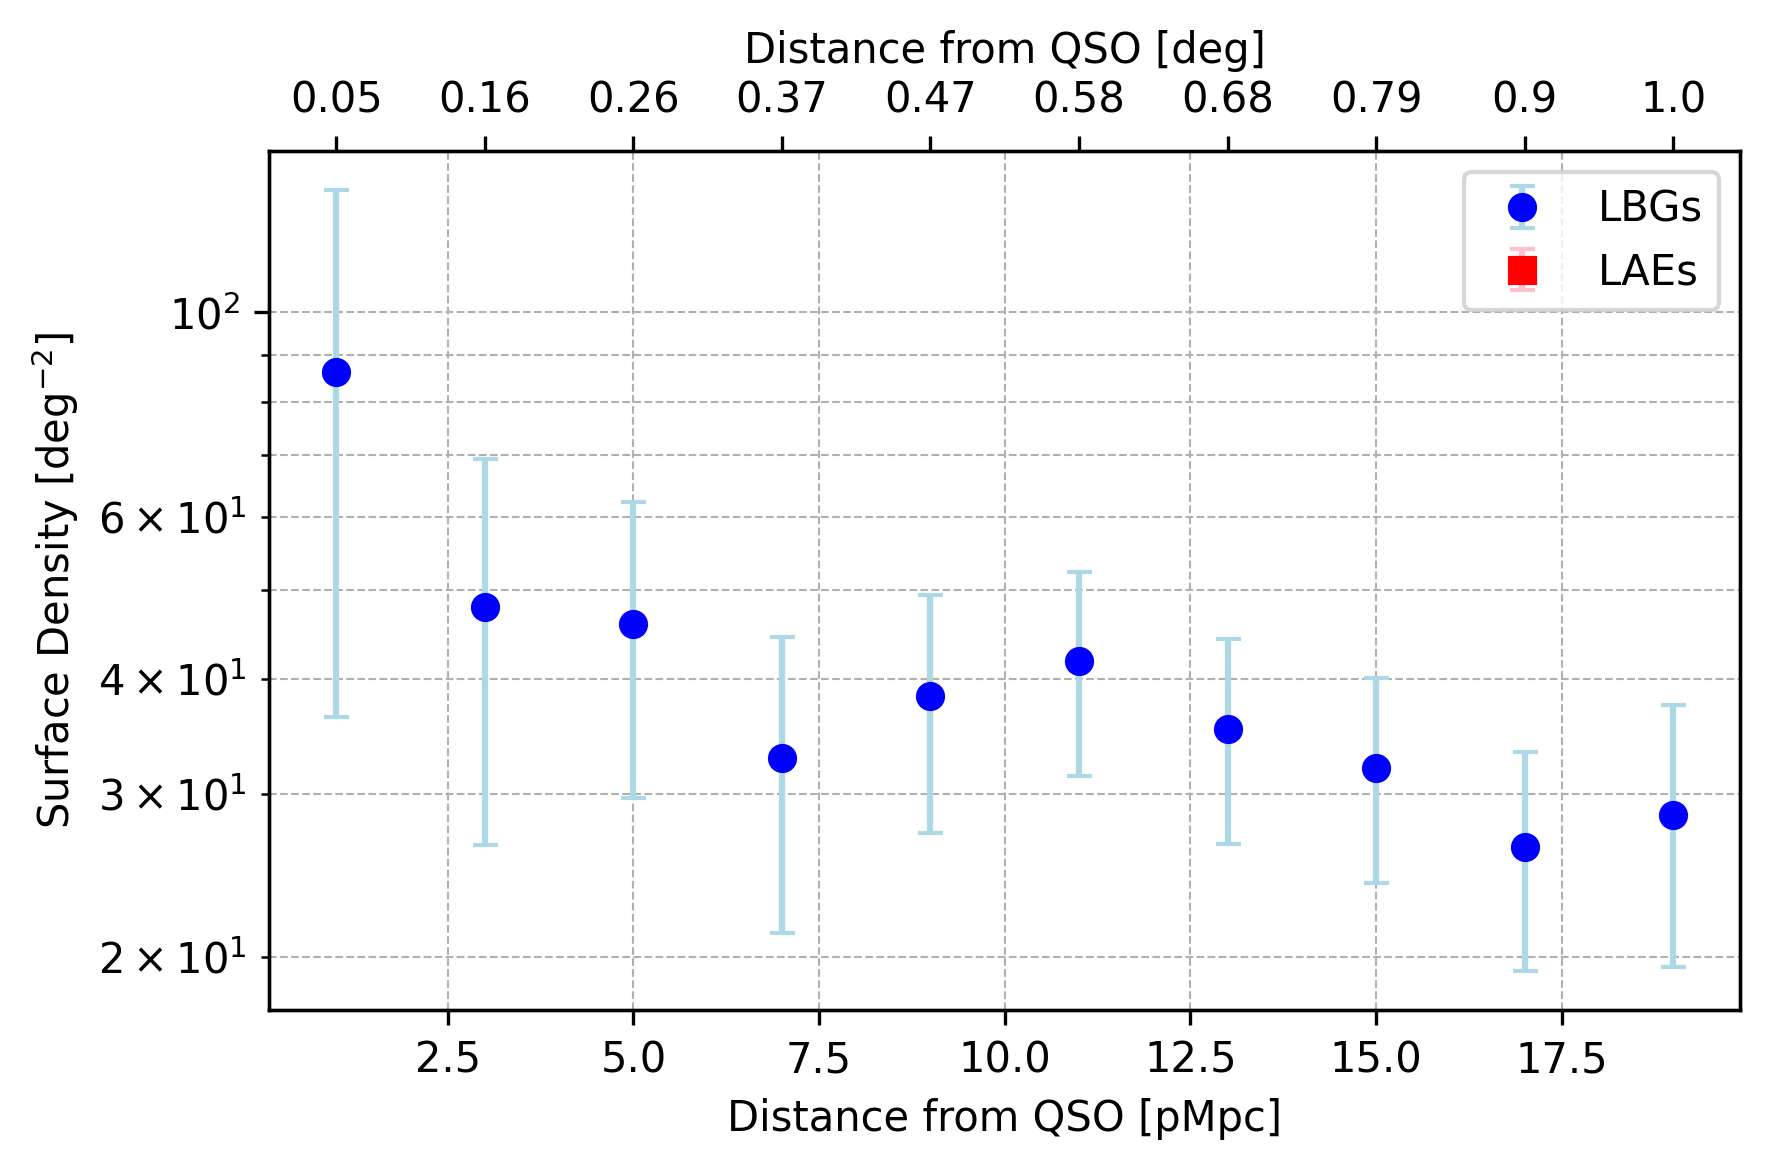

Saved combined plot: plots/lbg_lae_surface_density.png


In [29]:
# ----------------------------
# Combined Surface Density Plot
# ----------------------------
def plot_combined_surface_density(radii_mpc, radii_deg, counts_lbg, areas_lbg, counts_lae, areas_lae, outfile):
    # Convert areas to float
    areas_lbg = np.array([a.value for a in areas_lbg])
    areas_lae = np.array([a.value for a in areas_lae])

    # Surface densities
    y_lbg = counts_lbg / areas_lbg
    yerr_lbg = np.sqrt(counts_lbg) / areas_lbg

    y_lae = counts_lae / areas_lae
    yerr_lae = np.sqrt(counts_lae) / areas_lae

    fig, ax = plt.subplots(figsize=(6,4), dpi=300)

    # Plot LBGs
    ax.errorbar(radii_mpc, y_lbg, yerr=yerr_lbg, fmt='o', color='blue', ecolor='lightblue', capsize=3, label='LBGs')

    # Plot LAEs
    ax.errorbar(radii_mpc, y_lae, yerr=yerr_lae, fmt='s', color='red', ecolor='pink', capsize=3, label='LAEs')

    ax.set_yscale('log')
    ax.set_xlabel("Distance from QSO [pMpc]")
    ax.set_ylabel("Surface Density [deg$^{-2}$]")
    ax.legend()
    ax.grid(True, which='both', ls='--', lw=0.5)

    # Secondary x-axis in degrees
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from QSO [deg]")

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()
    print(f"Saved combined plot: {outfile}")


# Call the function with your DECAM and LAE counts
plot_combined_surface_density(
    radii_mid_mpc.value,
    radii_mid_deg,
    counts_decam, areas_decam,   # LBGs
    counts_lae, areas_lae,       # LAEs
    "plots/lbg_lae_surface_density.png"
)

In [ ]:
print("Total LAEs:", len(dist_lae))
print("Distances (deg):", dist_lae.to(u.deg))
print("Counts per bin:", counts_lae)